#### `parallel_tool_calls=False` <br>
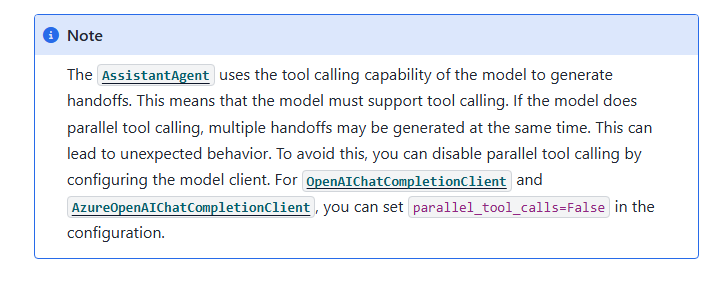



In [1]:
from typing import Any, Dict, List

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.ui import Console
from autogen_agentchat.teams import Swarm
from autogen_agentchat.conditions import TextMentionTermination, HandoffTermination
from autogen_agentchat.messages import HandoffMessage
from autogen_ext.models.openai import OpenAIChatCompletionClient

In [2]:
import os
from dotenv import load_dotenv

# Load API Key
load_dotenv()

api_key= os.getenv("OPENAI_API_KEY")

In [24]:
# Model Client

model_client= OpenAIChatCompletionClient(model='gpt-4o', api_key=api_key, parallel_tool_call=False)

model_client

#### Tool

In [25]:
def refund_flight(flight_PNR: str) -> str:
    return f"Refunded Flight with PNR {flight_PNR}"

#### Travel Agent

In [26]:
travel_agents= AssistantAgent(
    name='travel_agents',
    model_client=model_client,
    handoffs=["flights_refunder", "user"],
    system_message="""You are a travel agent.
    The flights_refunder is in charge of refunding flights.
    If you need information from the user, you must first send your message, then you can handoff to the user.
    Use TERMINATE when the travel planning is complete."""
)

`Now in this case, flights_refunder agents handoffs to only travel_agents not to user`

In [27]:
flights_refunder= AssistantAgent(
    name="flights_refunder",
    model_client=model_client,
    handoffs=["travel_agents"],
    tools=[refund_flight],
    system_message="""You are an agent specialized in refunding flights.
    You only need flight PNR numbers to refund a flight.
    You have the ability to refund a flight using the refund_flight tool.
    If you need information from the user, you must first send your message, then you can handoff to the user.
    When the transaction is complete, handoff to the travel agent to finalize.""",
)

#### Termination Condition

In [28]:
termination= HandoffTermination(target="user") | TextMentionTermination("TERMINATE")

#### Swarm Teams

In [29]:
teams= Swarm(
    [travel_agents, flights_refunder],
    termination_condition= termination,
    max_turns=20
    )

#### Reset Swarm Teams

In [30]:
await teams.reset()

In [31]:
task= 'I want to refund my flight'

async def run_team_stream() -> None:
    task_result= await Console(teams.run_stream(task=task))

    last_message= task_result.messages[-1]

    while(isinstance(last_message, HandoffMessage) and last_message.target=='user'):
        user_ka_message= input("User: ")

        task_result= await Console(teams.run_stream(task=HandoffMessage(source='user', target=last_message.source, content=user_ka_message)))

        last_message= task_result.messages[-1]

await run_team_stream()

---------- TextMessage (user) ----------
I want to refund my flight
---------- ToolCallRequestEvent (travel_agents) ----------
[FunctionCall(id='call_MlXDuo3DQ63K07V7biNrEU9M', arguments='{}', name='transfer_to_flights_refunder')]
---------- ToolCallExecutionEvent (travel_agents) ----------
[FunctionExecutionResult(content='Transferred to flights_refunder, adopting the role of flights_refunder immediately.', name='transfer_to_flights_refunder', call_id='call_MlXDuo3DQ63K07V7biNrEU9M', is_error=False)]
---------- HandoffMessage (travel_agents) ----------
Transferred to flights_refunder, adopting the role of flights_refunder immediately.
---------- TextMessage (flights_refunder) ----------
I can help you with that. Could you please provide me with your flight PNR number?
---------- TextMessage (flights_refunder) ----------
I need your flight PNR number to process the refund for your flight. Could you please provide it?
---------- ToolCallRequestEvent (flights_refunder) ----------
[Functi